In [1]:

import json
import requests
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append("..")
from utils.balanced_builders_hdf import *
from models.autoencoder_classifier import *
from config import *
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from final_pipline.IG import *
import pickle
from scipy.ndimage import gaussian_filter
from final_pipline.xrd_sum import *
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram
import h5py
from final_pipline.IG_prototypes import *

In [2]:
sg = build_balanced_sg_loaders_from_h5(
    h5_path=xrd_dataset,
    min_count_sg=20000,
    per_class_cap_sg=20000,
    batch_size=256,
    val_split=0.1,
    test_split=0.1,
    seed=42,
    num_workers=4,
)

print(sg["num_classes"])
print(sg["sizes"])

22
{'train': 352000, 'val': 44000, 'test': 44000}


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load checkpoint FIRST
checkpoint = torch.load(
    SG_Cls,
    map_location=device
)

# Recreate model using checkpoint metadata (NOT sg dict)
model = DeepConvAutoencoderClassifier(
    input_length=checkpoint["input_len"],
    latent_dim=64,
    cls_dim=128,
    num_classes=checkpoint["num_classes"],
    use_projection_head=True
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

label_map = checkpoint["label_map"]   

C:\Users\doaam\AppData\Local\Temp\ipykernel_12364\1624452917.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


In [5]:
with h5py.File(IG_database_SG, "r") as f:
    ig_train_igs = f["attributions"][:]        
    ig_train_classes = f["true_classes"][:]    

In [ ]:
protos, counts = build_ig_class_prototypes(
    IG_database_SG,
    num_classes=22
)

np.save(
   IG_Classes_Prototypes_SG,
    protos
)
print("Saved prototypes. counts =", counts)

In [6]:

# Example: plot sample index 2
#idx = 2
#plot_ig_only( ig_train_igs[idx],true_class=ig_train_classes[idx])

In [5]:
idx = 10
sample_ig = ig_train_igs[idx]

print("Entropy:", ig_entropy(sample_ig))
print("Top regions:", top_regions(sample_ig))


Entropy: 7.0176973
Top regions: [(875, 895, 885, 0.29768192768096924), (1999, 2019, 2009, -0.18409156799316406), (1573, 1593, 1583, -0.1272655874490738), (1086, 1106, 1096, 0.07984243333339691), (527, 547, 537, -0.07743500918149948), (335, 355, 345, -0.07547489553689957)]


In [8]:
#plot_mean_xrd_patterns_by_class_separate(
#    cs["train_loader"],
#    class_names= cs["class_names"],
#    max_patterns_per_class=7000)

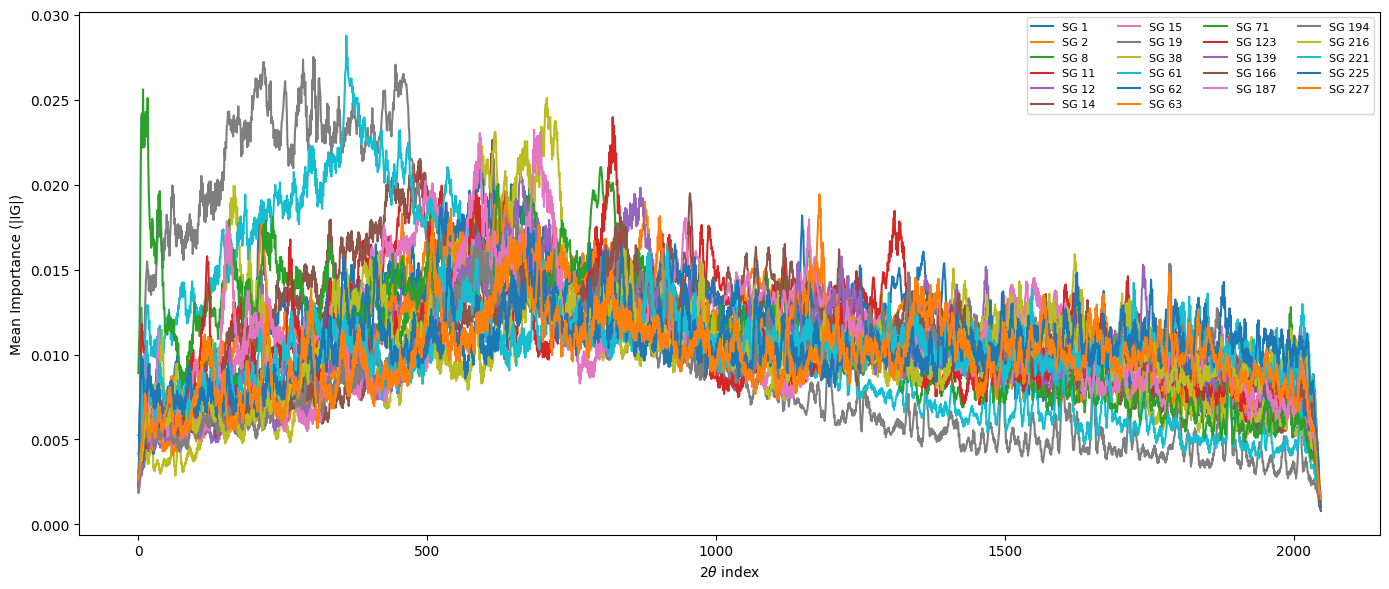

In [10]:
space_groups = [
    1, 2, 8, 11, 12, 14, 15, 19, 38, 61,
    62, 63, 71, 123, 139, 166, 187, 194,
    216, 221, 225, 227
]

# 1️ Use absolute IG values
ig_abs = np.abs(ig_train_igs)

# 2️ Compute mean IG per space group
mean_igs_sg = {}

for class_idx, sg in enumerate(space_groups):
    mask = ig_train_classes == class_idx
    mean_curve = ig_abs[mask].mean(axis=0)
    mean_igs_sg[sg] = mean_curve

# 3️ Plot
plt.figure(figsize=(14, 6))

for sg in space_groups:
    plt.plot(mean_igs_sg[sg], label=f"SG {sg}")

plt.xlabel(r"2$\theta$ index")
plt.ylabel("Mean Importance (|IG|)")
plt.legend(ncol=4, fontsize=8)  
plt.tight_layout()
plt.show()

In [ ]:
mean_sg_xrd = compute_mean_xrd_by_spacegroup(
    dataloader=sg["train_loader"],      
    sg_class_names=space_groups,
    max_patterns=7000,
    verbose=True
)

Collected patterns per SG: {1: 1000, 2: 1000, 8: 1000, 11: 1000, 12: 1000, 14: 1000, 15: 1000, 19: 1000, 38: 1000, 61: 1000, 62: 1000, 63: 1000, 71: 1000, 123: 1000, 139: 1000, 166: 1000, 187: 1000, 194: 1000, 216: 1000, 221: 1000, 225: 1000, 227: 1000}


IG counts per SG: {1: 16000, 2: 16000, 8: 16000, 11: 16000, 12: 16000, 14: 16000, 15: 16000, 19: 16000, 38: 16000, 61: 16000, 62: 16000, 63: 16000, 71: 16000, 123: 16000, 139: 16000, 166: 16000, 187: 16000, 194: 16000, 216: 16000, 221: 16000, 225: 16000, 227: 16000}


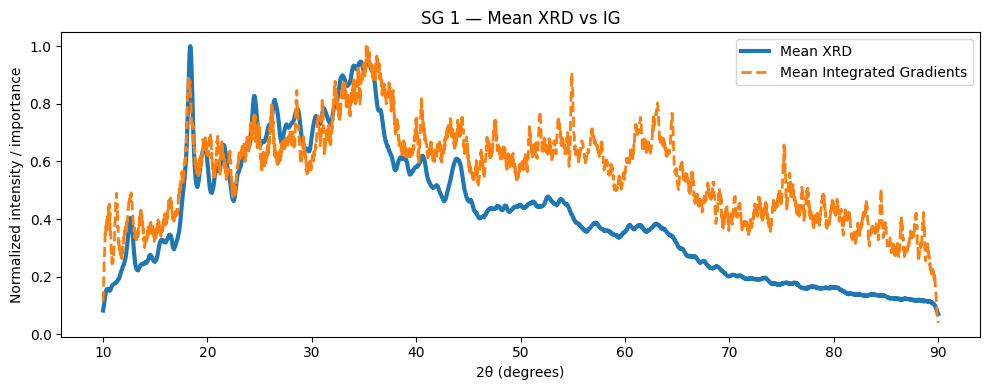

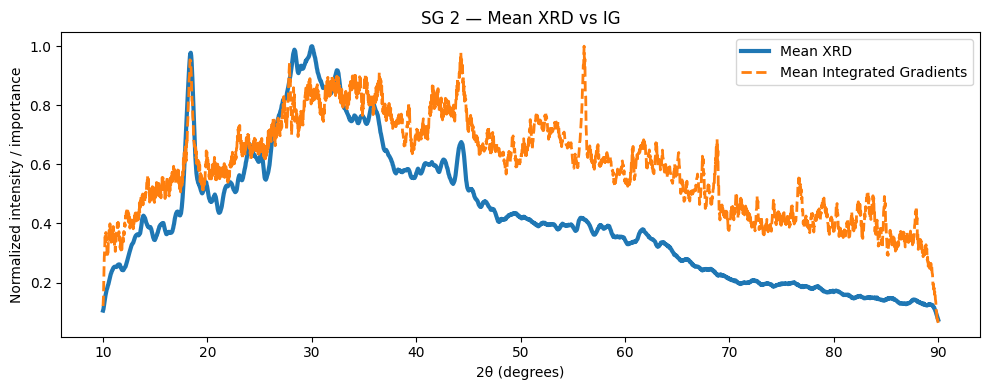

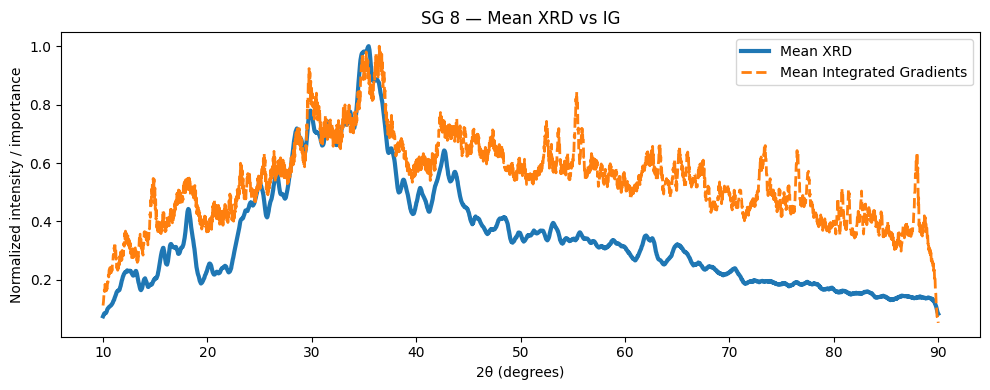

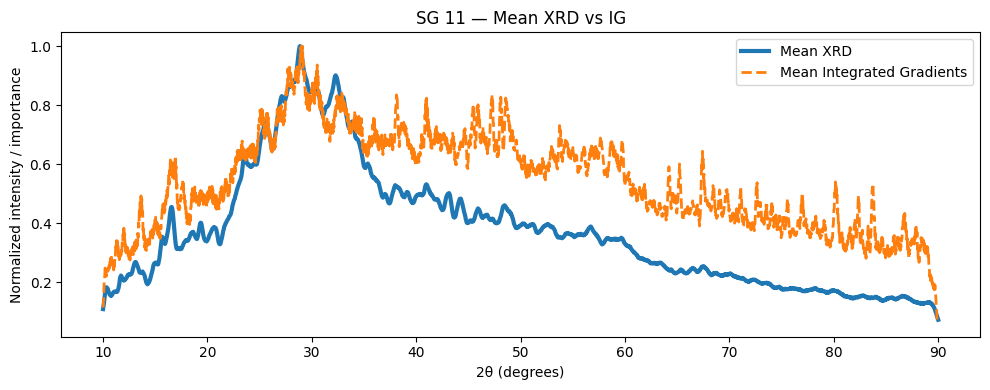

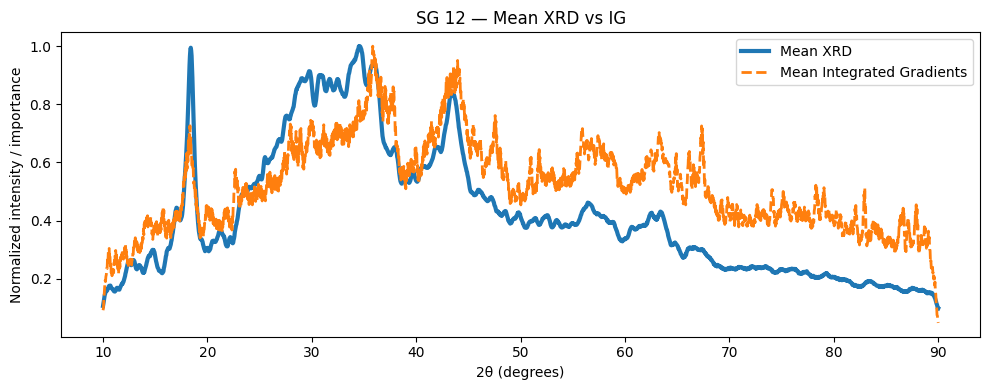

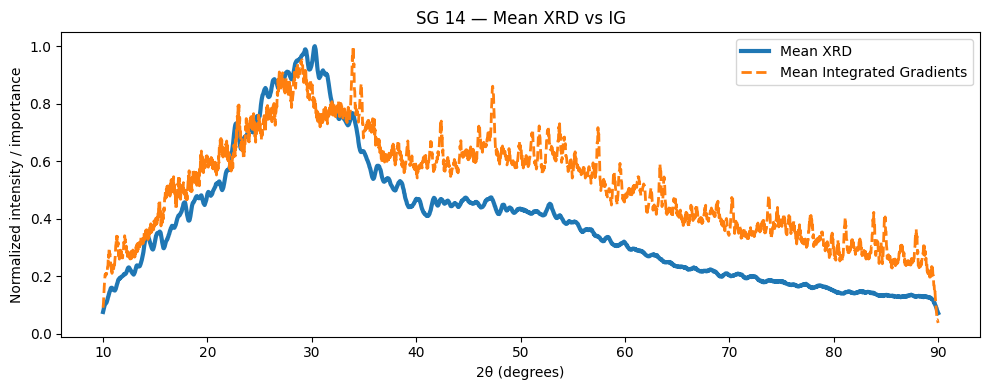

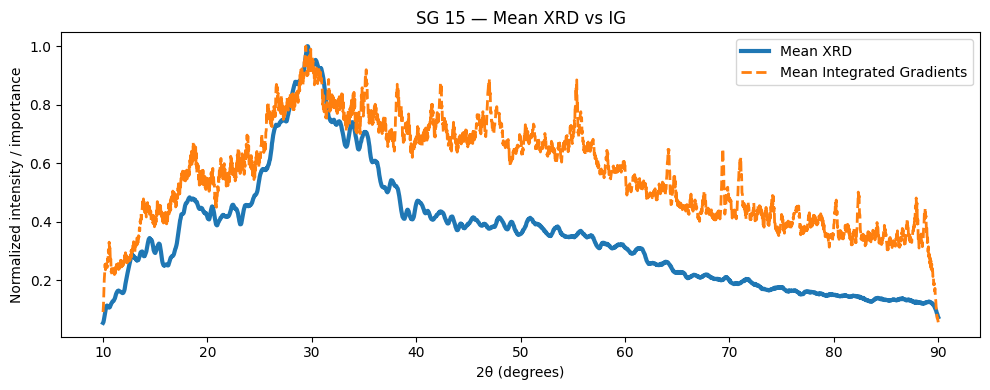

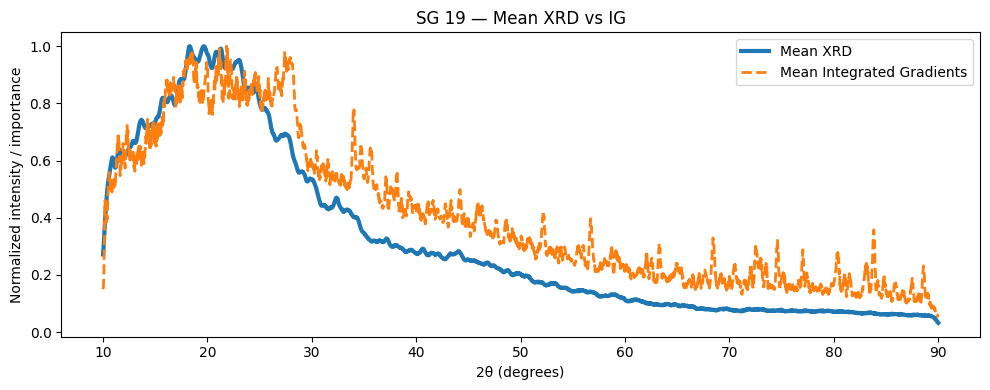

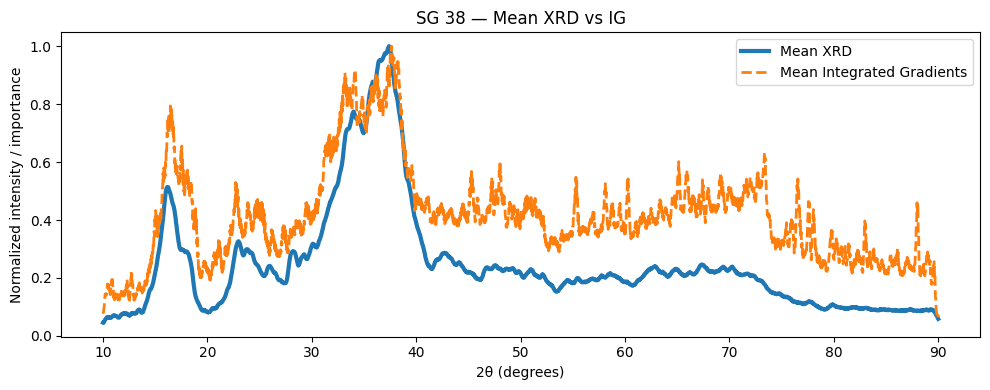

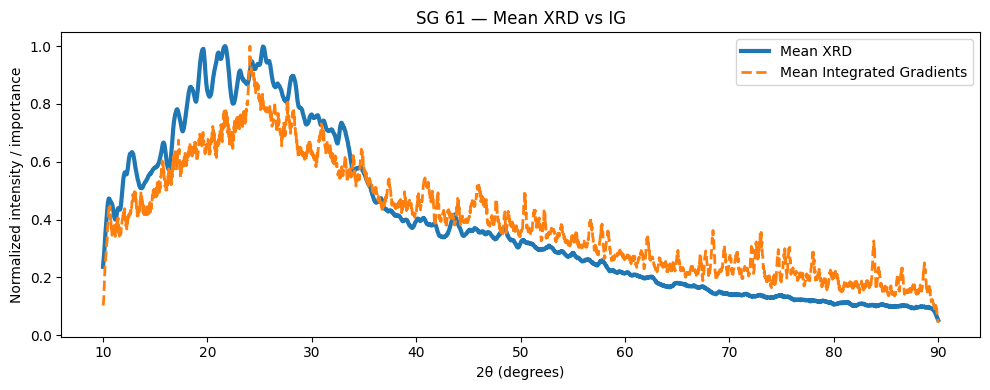

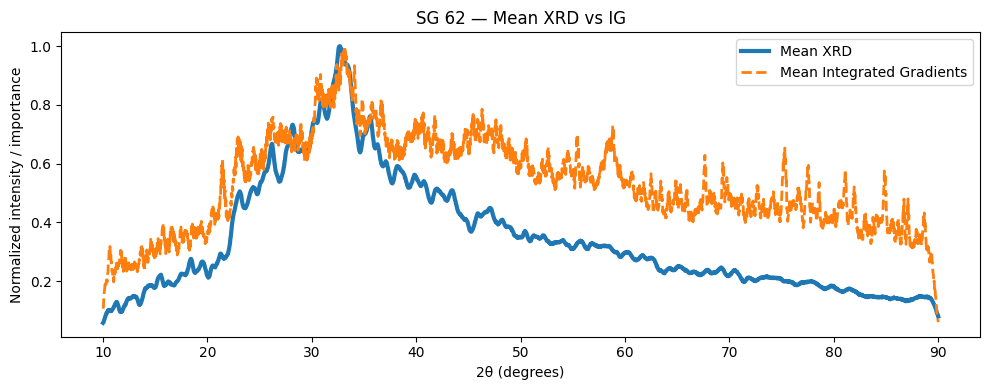

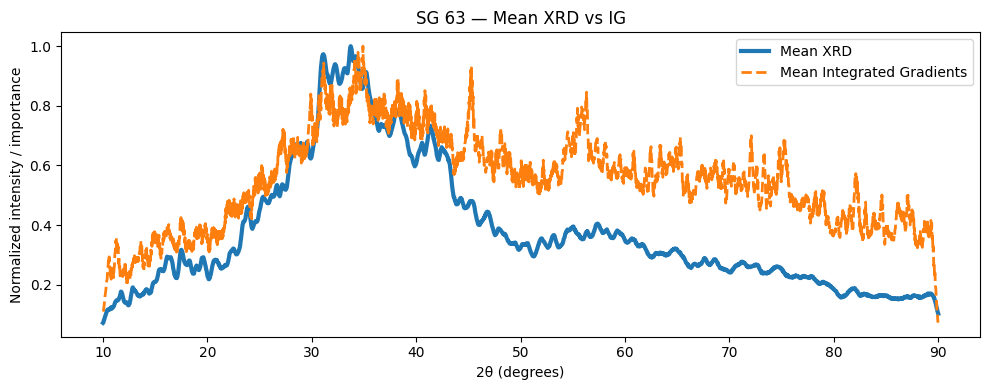

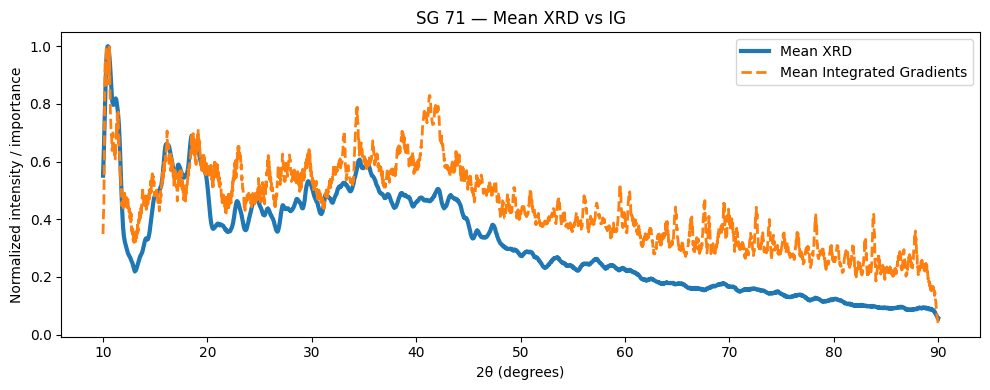

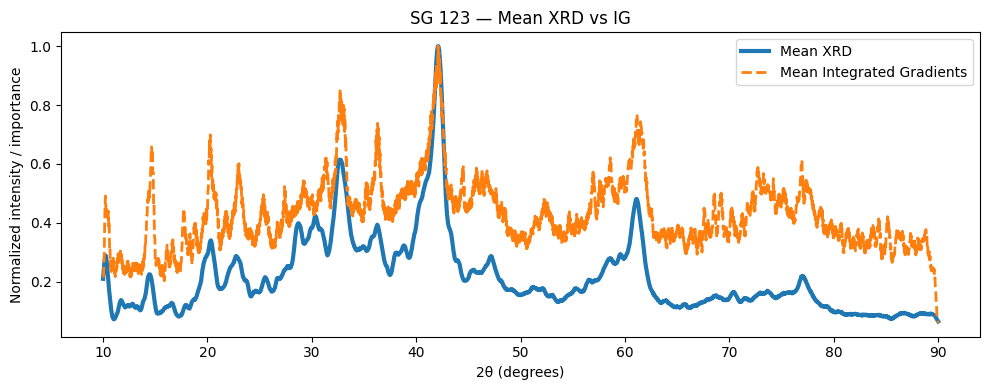

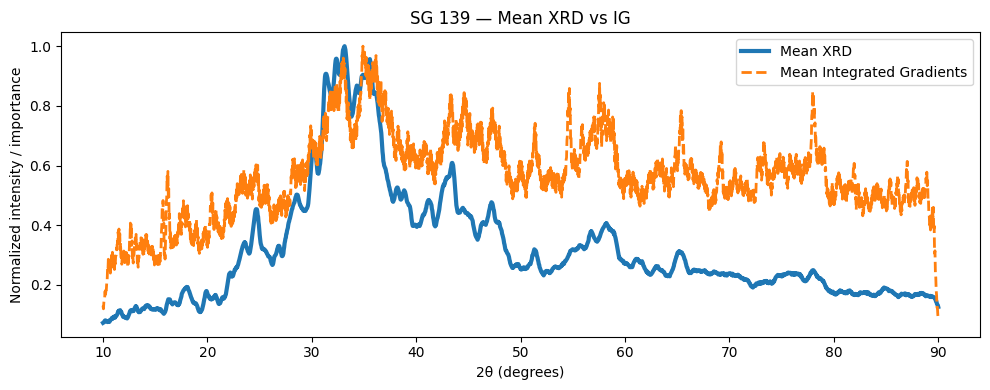

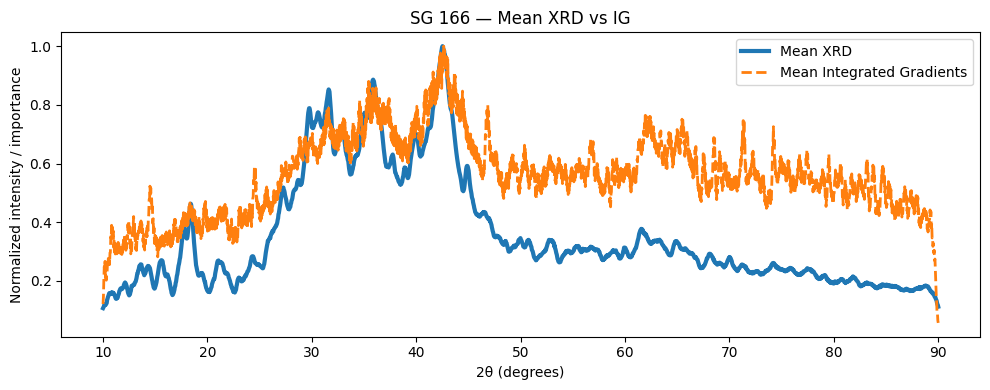

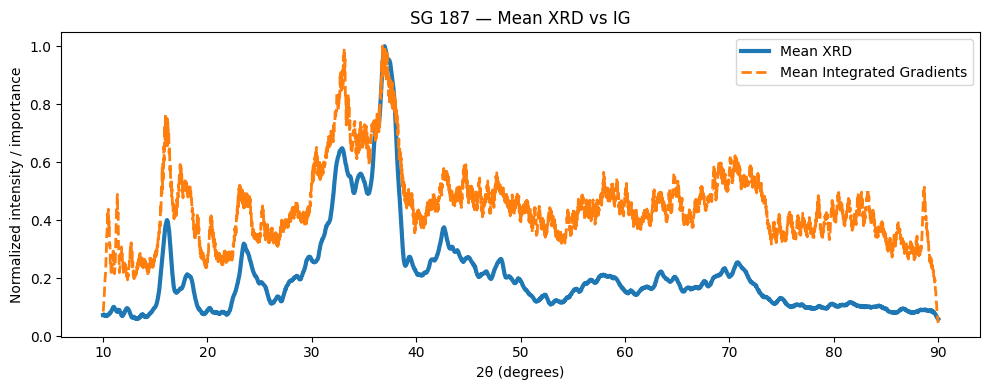

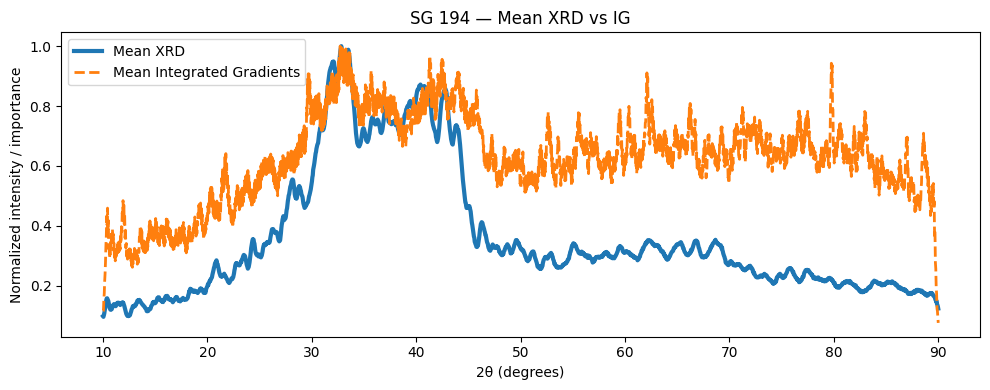

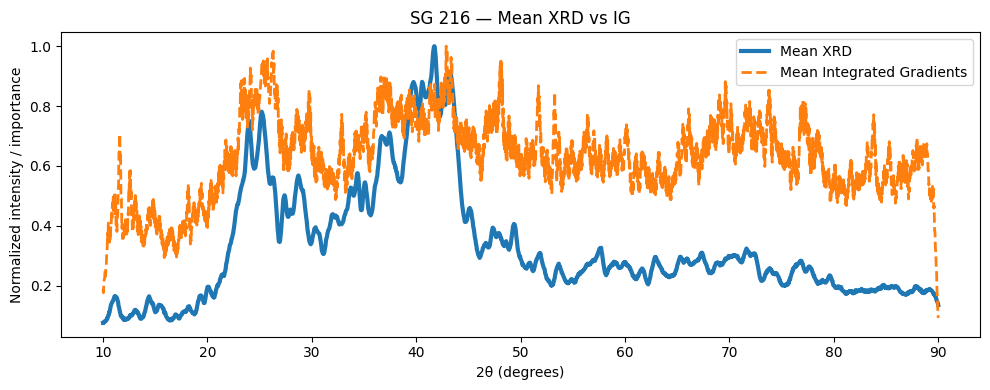

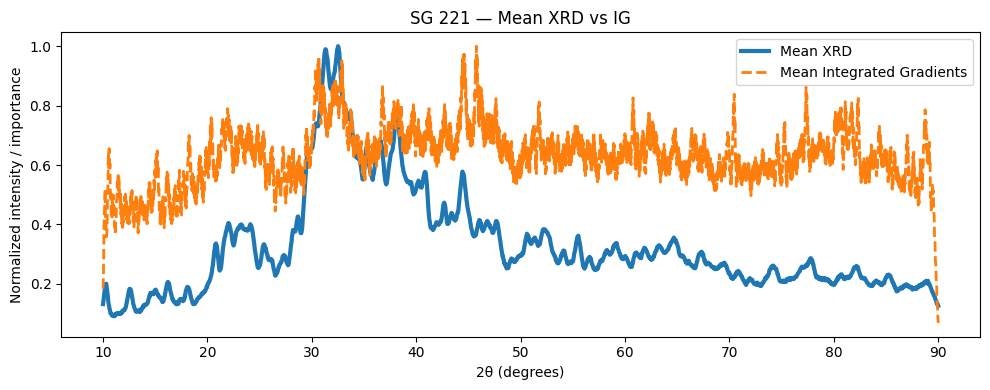

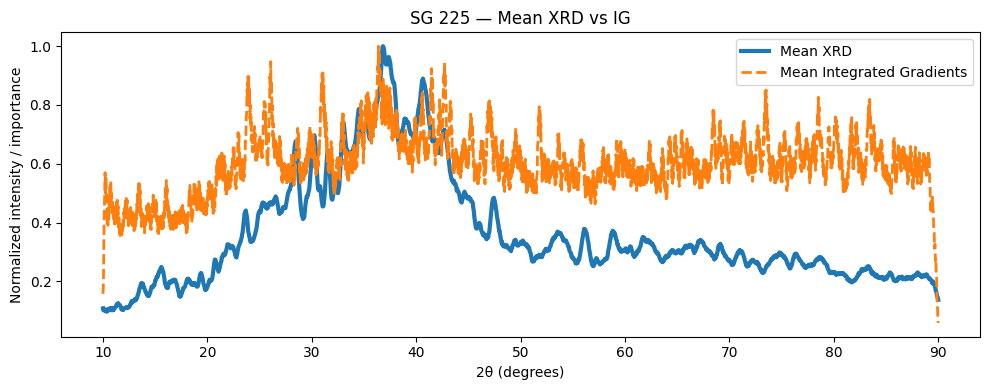

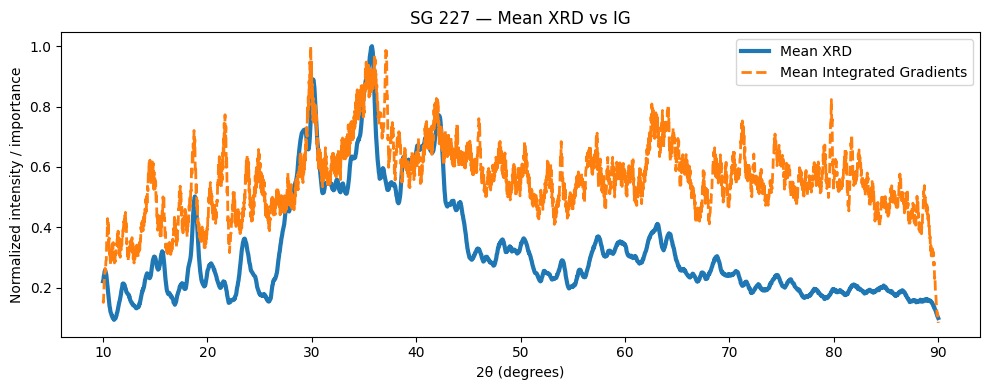

In [ ]:
ig_abs = np.abs(ig_train_igs).astype(np.float32)
mean_sg_igs = compute_mean_ig_by_spacegroup(
    ig_vectors=ig_abs,
    labels=ig_train_classes,
    sg_class_names=space_groups
)
plot_mean_xrd_vs_mean_ig_by_sg(
    mean_sg_xrd=mean_sg_xrd,
    mean_sg_ig=mean_sg_igs,
    sg_class_names=space_groups
)

In [6]:

# -------------------------------------------------
#  Run SG IG fingerprint analysis 
# -------------------------------------------------
def run_sg_ig_fingerprint_analysis(
    ig_train_igs,
    ig_train_classes,
    sg_class_names,
    top_regions_fn,            # your existing top_regions() function
    smooth_sigma=1,
    x_min=10,
    x_max=90
):
    sg_class_names = [int(sg) for sg in sg_class_names]
    num_classes = len(sg_class_names)

    # 1) Mean IG per class
    mean_imp = compute_mean_ig_by_sg(
        ig_train_igs=ig_train_igs,
        ig_train_classes=ig_train_classes,
        sg_class_names=sg_class_names,
        use_abs=True
    )  # (22, 2048)

    # 2) Build matrix + normalize per class
    M = mean_imp.copy()
    M_norm = M / (np.max(M, axis=1, keepdims=True) + 1e-8)

    # Optional smoothing
    if smooth_sigma is not None and smooth_sigma > 0:
        M_norm = gaussian_filter(M_norm, sigma=smooth_sigma)

    # 3) 2θ axis
    N = M.shape[1]
    two_theta = np.linspace(x_min, x_max, N)

    # 4) Print top regions per SG
    print("\nTop IG regions per SPACE GROUP:")

    for i, sg in enumerate(sg_class_names):
        regions = top_regions_fn(M_norm[i])

        print(f"\nSG: {sg}")
        for (lo, hi, center, score) in regions:
            print(
                f"  2θ [{two_theta[lo]:.2f}, {two_theta[hi]:.2f}] "
                f"(center={two_theta[center]:.2f})  score={score:.4f}"
            )

    # 5) IG heatmap
    plt.figure(figsize=(14, 7))
    im = plt.imshow(
        M_norm,
        aspect="auto",
        cmap="inferno",
        extent=[two_theta[0], two_theta[-1], 0, num_classes],
        origin="lower"
    )
    plt.colorbar(im, label="Normalized Mean IG Importance")
    plt.yticks(np.arange(num_classes) + 0.5,
            [str(sg) for sg in sg_class_names])
    plt.xlabel("2θ (degrees)")
    plt.ylabel("Space Group")

    for i in range(num_classes):
        plt.axhline(i, color="white", linewidth=0.3)

    plt.tight_layout()
    plt.savefig(IG_Heatmap_SG,
                format="pdf",
                bbox_inches="tight")
    plt.close()

    # 6) Distances
    cos_sim = cosine_similarity(M_norm)
    cos_dist = 1 - cos_sim

    corr_dist = pairwise_distances(M_norm, metric="correlation")

    # 7) Plot distance heatmaps
    #plt.figure(figsize=(8, 7))
    #im = plt.imshow(cos_dist, cmap="viridis")
    #plt.xticks(range(num_classes), [str(sg) for sg in sg_class_names], rotation=90)
    #plt.yticks(range(num_classes), [str(sg) for sg in sg_class_names])
    #plt.colorbar(im, label="Cosine Distance")
    #plt.tight_layout()
    #plt.show()

    #plt.figure(figsize=(8, 7))
    #im = plt.imshow(corr_dist, cmap="magma")
    #plt.xticks(range(num_classes), [str(sg) for sg in sg_class_names], rotation=90)
    #plt.yticks(range(num_classes), [str(sg) for sg in sg_class_names])
    #plt.colorbar(im, label="Correlation Distance")
    #plt.tight_layout()
    #plt.show()

    # 8) Hierarchical clustering
    Z = linkage(M_norm, method="ward")

    plt.figure(figsize=(14, 7))   # larger figure

    dendrogram(
        Z,
        labels=[str(sg) for sg in sg_class_names],
        leaf_font_size=18        
    )

    plt.xticks(rotation=45)        # prevent overlap
    plt.ylabel("Distance", fontsize=18)
    plt.xlabel("Space Group", fontsize=18)

    plt.tight_layout()
    plt.savefig(
        "IG_Cosine_SG_pdf",
        format="pdf",
        bbox_inches="tight"
    )
    plt.close()
    # 9) Mean inter-class distance
    upper_tri = cos_dist[np.triu_indices(num_classes, k=1)]
    print("\nMean cosine inter-class distance:", float(upper_tri.mean()))

    upper_tri_corr = corr_dist[np.triu_indices(num_classes, k=1)]
    print("Mean correlation inter-class distance:", float(upper_tri_corr.mean()))

    return {
        "M_norm": M_norm,
        "two_theta": two_theta,
        "cos_dist": cos_dist,
        "corr_dist": corr_dist
    }
# sg_class_names should be your 22 SG numbers list
sg_class_names = sg["class_names"]  # or your explicit list

outputs = run_sg_ig_fingerprint_analysis(
    ig_train_igs=ig_train_igs,
    ig_train_classes=ig_train_classes,
    sg_class_names=sg_class_names,
    top_regions_fn=top_regions,      
    smooth_sigma=1,
    x_min=10,
    x_max=90
)

IG samples per SG: {1: 16000, 2: 16000, 8: 16000, 11: 16000, 12: 16000, 14: 16000, 15: 16000, 19: 16000, 38: 16000, 61: 16000, 62: 16000, 63: 16000, 71: 16000, 123: 16000, 139: 16000, 166: 16000, 187: 16000, 194: 16000, 216: 16000, 221: 16000, 225: 16000, 227: 16000}

Top IG regions per SPACE GROUP:

SG: 1
  2θ [34.89, 35.68] (center=35.29)  score=0.9419
  2θ [35.87, 36.65] (center=36.26)  score=0.9214
  2θ [35.32, 36.11] (center=35.72)  score=0.8878
  2θ [34.04, 34.82] (center=34.43)  score=0.8783
  2θ [17.93, 18.72] (center=18.32)  score=0.8701
  2θ [34.47, 35.25] (center=34.86)  score=0.8672

SG: 2
  2θ [34.82, 35.60] (center=35.21)  score=0.9051
  2θ [36.07, 36.85] (center=36.46)  score=0.9004
  2θ [35.64, 36.42] (center=36.03)  score=0.8604
  2θ [34.35, 35.13] (center=34.74)  score=0.8601
  2θ [33.68, 34.47] (center=34.07)  score=0.8309
  2θ [36.50, 37.28] (center=36.89)  score=0.8266

SG: 8
  2θ [36.11, 36.89] (center=36.50)  score=0.8636
  2θ [34.82, 35.60] (center=35.21)  score

In [ ]:
model.to(device)
model.eval()

# Precompute and move training IGs to GPU ONCE
train_igs = np.abs(ig_train_igs).astype(np.float32)
train_igs = train_igs / (
    np.linalg.norm(train_igs, axis=1, keepdims=True) + 1e-8
)

train_igs_torch = torch.tensor(train_igs).to(device)
train_classes_torch = torch.tensor(ig_train_classes).to(device)


with h5py.File(external_test_dataset, "r") as f:

    x_mis = f["xrd"][:]
    y_mis = f["labels"][:]
    crystal_systems = f["crystalsystems"][:]
    compositions = f["compositions"][:]

# --------------------------------------------------
# Create x_test compatible with IG single inference
# --------------------------------------------------

x_test = x_mis.astype(np.float32)

print("x_test shape:", x_test.shape)

result_sg = run_single_inference(
    x_sample=x_test[0],
    model=model,
    class_names=space_groups,
    train_igs_torch=train_igs_torch,
    train_classes_torch=train_classes_torch,
    device=device
)

print(result_sg)


x_test shape: (465, 2048)
{'model_prediction': 216, 'model_confidence': 0.9999979734420776, 'model_topk': [(216, 0.9999979734420776), (221, 1.9965548290201696e-06), (225, 2.6212399362179895e-08)], 'ig_prediction': 221, 'ig_similarity': 0.2559404671192169, 'ig_topk': [(221, 0.2559404671192169), (194, 0.2123941034078598), (194, 0.2118576616048813)]}


In [11]:
class_mean_ig = build_class_mean_ig(
    ig_train_igs,
    ig_train_classes,
    num_classes=22
)

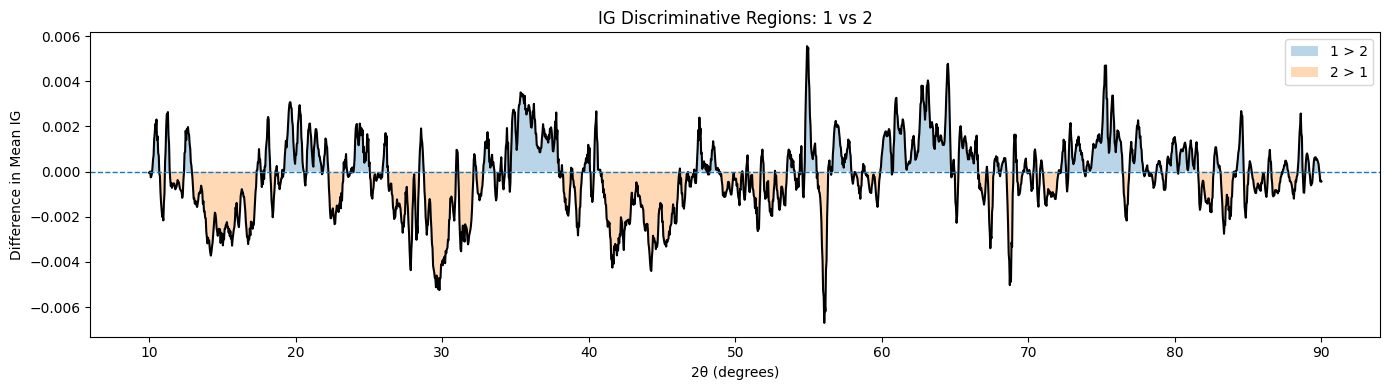

In [22]:
diff = plot_class_difference(
    class_mean_ig,
   space_groups,
    1,
    2
)